# KLASIFIKASI GENRE GAME BERDASARKAN SINOPSIS (MULTI-LABEL)
---
**Author:** *Muhammad Wira Widhana [24.55.2717]*

## Library & Load Dataset

library 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import ast
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier

from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import classification_report, hamming_loss, precision_score, recall_score, f1_score, mean_squared_error

In [2]:
# pertama kali saja:

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# digunakan di preprocessing
english_stopwords = set(stopwords.words('english'))
stemmer = PorterStemmer()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ShirO_KurO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ShirO_KurO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ShirO_KurO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Load dan Memeriksa Data (Data Loading & EDA)

Load Dataset

In [3]:
# Load Dataset
df_raw = pd.read_csv('games_fixed.csv')

print("Ukuran awal dataset:", df_raw.shape)
df_raw.head()

Ukuran awal dataset: (122611, 36)


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Median playtime two weeks,Average playtime forever,Median playtime forever,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,10,Counter-Strike,"Nov 1, 2000",10000000 - 20000000,7323,0,1.99,80,0,Play the world's number 1 online action game. ...,...,99,10735,185,['Valve'],['Valve'],"['Multi-player', 'PvP', 'Online PvP', 'Shared/...",['Action'],"{'Action': 5504, 'FPS': 4929, 'Multiplayer': 3...",['https://shared.akamai.steamstatic.com/store_...,[]
1,100,Counter-Strike: Condition Zero,"Mar 1, 2004",10000000 - 20000000,83,0,1.99,80,0,"With its extensive Tour of Duty campaign, a ne...",...,1,431,32,['Valve'],['Valve'],"['Single-player', 'Multi-player', 'Color Alter...",['Action'],"{'Action': 1339, 'FPS': 979, 'Shooter': 723, '...",['https://shared.akamai.steamstatic.com/store_...,[]
2,1000000,ASCENXION,"May 14, 2021",0 - 20000,0,0,1.49,0,1,ASCENXION is a 2D shoot 'em up game where you ...,...,0,0,0,['IndigoBlue Game Studio'],['PsychoFlux Entertainment'],"['Single-player', 'Steam Achievements', 'Parti...","['Action', 'Adventure', 'Indie']","{""Shoot 'Em Up"": 186, 'Metroidvania': 181, 'Bu...",['https://shared.akamai.steamstatic.com/store_...,[]
3,1000010,Crown Trick,"Oct 16, 2020",500000 - 1000000,14,0,4.99,0,2,Crown Trick is a beautifully animated rogue-li...,...,0,702,397,['NEXT Studios'],"['Team17', 'NEXT Studios']","['Single-player', 'Steam Achievements', 'Steam...","['Adventure', 'Indie', 'RPG', 'Strategy']","{'Rogue-like': 275, 'Turn-Based Combat': 258, ...",['https://shared.akamai.steamstatic.com/store_...,[]
4,1000030,"Cook, Serve, Delicious! 3?!","Oct 14, 2020",100000 - 200000,27,0,4.99,75,1,Hit the road in this massive sequel to the mil...,...,0,281,118,['Vertigo Gaming Inc.'],['Vertigo Gaming Inc.'],"['Single-player', 'Multi-player', 'Co-op', 'Sh...","['Action', 'Indie', 'Simulation', 'Strategy']","{'Typing': 227, 'Management': 219, 'Difficult'...",['https://shared.akamai.steamstatic.com/store_...,[]


>Penjelasan singkat: Membaca dataset `games_fixed.csv` yang merupakan dataset dari kaggle 

Exploratory Data Analysis (EDA)

In [4]:
# Exploratory Data Analysis (EDA)

df = df_raw[['Name', 'About the game', 'Genres']].copy()

df.rename(columns={
    'Name': 'title',
    'About the game': 'synopsis',
    'Genres': 'genre_raw'
}, inplace=True)

print("Jumlah data setelah seleksi kolom:", df.shape)
df.sample(5)

Jumlah data setelah seleksi kolom: (122611, 3)


,title,synopsis,genre_raw
47903,Pixel Art Academy: Learn Mode,Pixel Art Academy is an educational game for l...,"['Simulation', 'Animation & Modeling', 'Design..."
18312,What The Dub?!,What The Dub?! is a multiplayer party game whe...,"['Casual', 'Indie']"
37020,Omnichess: Chess Variants,Omnichess is the game that allows you to desig...,"['Casual', 'Indie', 'Strategy']"
31939,天下镖局 Playtest,NaN,[]
33047,Trade Bots: A Technical Analysis Simulation,Trade Bots is an educational simulation game f...,"['Indie', 'Simulation', 'Strategy']"


Cek missing values

In [5]:
# Cek missing values
df.isna().sum()

title           1
synopsis     8448
genre_raw       0
dtype: int64

Hapus baris yang tidak punya sinopsis atau genre

In [6]:
# Hapus baris yang tidak punya sinopsis atau genre
df = df.dropna(subset=['synopsis', 'genre_raw']).reset_index(drop=True)

# Tambahan: hapus genre yang kosong secara konten, seperti [], [''], dll.
df['genre_raw'] = df['genre_raw'].astype(str).str.strip()

# Filter keluar string yang merepresentasikan list kosong
df = df[~df['genre_raw'].isin(['[]', "['']", '[""]', '', 'nan'])].reset_index(drop=True)

print("Jumlah data setelah drop NA dan genre kosong:", df.shape)

Jumlah data setelah drop NA dan genre kosong: (114022, 3)


In [7]:
df.sample(5)

,title,synopsis,genre_raw
11066,Shiro,Holo and Shiro are twin sisters who travel the...,"['Action', 'Adventure', 'Indie']"
65385,Color Splash: Fairies,Color Splash: Fairies is a charming and relaxi...,['Casual']
50461,无尽的冒险,Endless Adventure is an idle looting RPG. Free...,"['Adventure', 'Casual', 'Indie', 'RPG']"
85654,Mystery Island：Enigmatic Painting,"Unravel the mystery, explore the shadows lurki...",['Adventure']
45534,Food Boy,1980's Paperboy meets 2020's Food Delivery Ser...,['Indie']


## Normalisasi Genre

> **Pendekatan Multi-Label:** Berbeda dengan pendekatan single-label, di sini setiap game dapat memiliki lebih dari satu genre. Genre `indie` dan `casual` dibuang karena keduanya bukan genre gameplay murni — `indie` adalah label produksi/developer, sedangkan `casual` adalah segmentasi audiens/tingkat kesulitan, bukan jenis konten permainan.
>
> Genre target: **action, adventure, rpg, simulation** (4 genre gameplay murni).

In [8]:
# Genre target: 4 genre gameplay murni (tanpa 'indie' & 'casual')
target_genres = {'action', 'adventure', 'rpg', 'simulation'}

def parse_genre_list(genre_str):
    """
    Parse string genre seperti "['Action', 'Indie']" menjadi list python ['action', 'indie'].
    Parsing aman menggunakan ast.literal_eval.
    """
    if pd.isna(genre_str):
        return []
    
    if isinstance(genre_str, list):
        raw_list = genre_str
    else:
        text = str(genre_str).strip()
        try:
            raw_list = ast.literal_eval(text)
        except (ValueError, SyntaxError):
            raw_list = [g.strip() for g in text.split(',')]
    
    cleaned = [g.strip().lower() for g in raw_list if isinstance(g, str)]
    return cleaned

# Terapkan parsing ke seluruh kolom genre_raw
df['genre_list'] = df['genre_raw'].apply(parse_genre_list)

# Ambil hanya genre yang termasuk subset target (tanpa indie)
# CATATAN: di sini kita PERTAHANKAN semua genre target, tidak dipilih satu saja (multi-label)
df['genre_labels'] = df['genre_list'].apply(
    lambda lst: sorted(set(g for g in lst if g in target_genres))
)

# Hitung jumlah genre target per game
df['genre_count'] = df['genre_labels'].apply(len)

print("Distribusi jumlah genre target per game:")
print(df['genre_count'].value_counts().sort_index())

Distribusi jumlah genre target per game:
genre_count
0    25759
1    51293
2    27328
3     8309
4     1333
Name: count, dtype: int64


> **Penjelasan singkat:** Berbeda dengan single-label yang membuang game multi-genre (`genre_count > 1`), 
pendekatan multi-label **mempertahankan seluruh game** yang memiliki minimal satu genre target. 
Dengan demikian jumlah data yang dapat digunakan jauh lebih banyak.

In [9]:
# Buang game yang tidak punya genre target sama sekali
df_main = df[df['genre_count'] >= 1].copy().reset_index(drop=True)

print("Jumlah data multi-label (>=1 genre target):", df_main.shape)
df_main[['title', 'genre_raw', 'genre_labels', 'genre_count']].head(10)

Jumlah data multi-label (>=1 genre target): (88263, 6)


,title,genre_raw,genre_labels,genre_count
0,Counter-Strike,['Action'],[action],1
1,Counter-Strike: Condition Zero,['Action'],[action],1
2,ASCENXION,"['Action', 'Adventure', 'Indie']","[action, adventure]",2
3,Crown Trick,"['Adventure', 'Indie', 'RPG', 'Strategy']","[adventure, rpg]",2
4,"Cook, Serve, Delicious! 3?!","['Action', 'Indie', 'Simulation', 'Strategy']","[action, simulation]",2
5,我的一个多重人格朋友,"['Adventure', 'Casual', 'Indie', 'RPG', 'Simul...","[adventure, rpg, simulation]",3
6,Zengeon,"['Action', 'Adventure', 'Indie', 'RPG']","[action, adventure, rpg]",3
7,干支セトラ 陽ノ卷｜干支etc. 陽之卷,"['Adventure', 'Indie', 'RPG', 'Strategy']","[adventure, rpg]",2
8,Jumping Master(跳跳大咖),"['Action', 'Adventure', 'Casual', 'Free To Pla...","[action, adventure]",2
9,Tower of Origin2-Worm's Nest,"['Indie', 'RPG']",[rpg],1


Sebaran genre

In [10]:
# Hitung frekuensi kemunculan tiap genre (satu game bisa dihitung di beberapa genre)
from collections import Counter

genre_counter = Counter()
for labels in df_main['genre_labels']:
    genre_counter.update(labels)

genre_freq = pd.Series(genre_counter).sort_values(ascending=False)
print(genre_freq)

action        46131
adventure     45063
simulation    24083
rpg           20931
dtype: int64


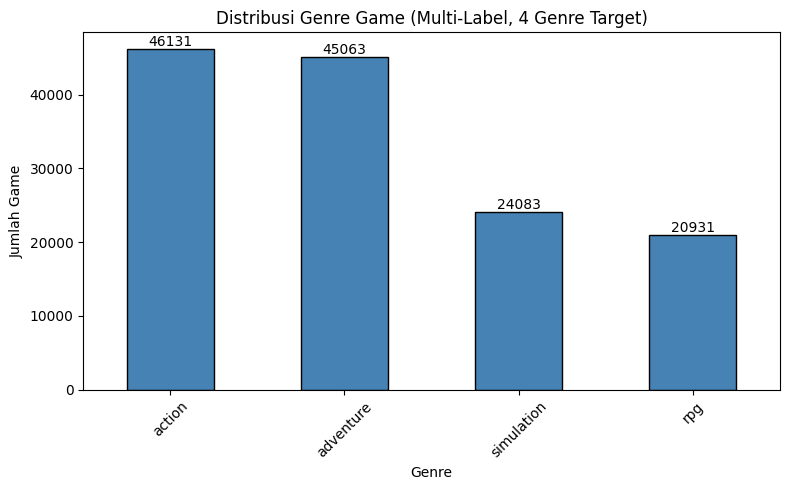

In [11]:
# Visualisasi distribusi genre (multi-label)
plt.figure(figsize=(8, 5))
ax = genre_freq.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribusi Genre Game (Multi-Label, 4 Genre Target)')
plt.xlabel('Genre')
plt.ylabel('Jumlah Game')
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## Filter Bahasa Inggris & Text Cleaning

In [12]:
# TEXT CLEANING & LANGUAGE FILTERING (ENGLISH-ONLY)
def basic_english_filter(text):
    
    # Filter sederhana untuk memastikan sinopsis dominan karakter Latin dan tidak terlalu pendek.
   
    if not isinstance(text, str):
        return False
    
    clean = re.sub(r'[^A-Za-z\s]', ' ', text)
    clean = re.sub(r'\s+', ' ', clean).strip()
    
    if len(clean.split()) < 3:
        return False
    
    ratio = len(clean) / max(len(text), 1)
    return ratio >= 0.7

df_main['is_english'] = df_main['synopsis'].apply(basic_english_filter)
print(df_main['is_english'].value_counts())

df_main = df_main[df_main['is_english']].drop(columns=['is_english']).reset_index(drop=True)
print("Jumlah data setelah filter bahasa Inggris:", df_main.shape)

is_english
True     86539
False     1724
Name: count, dtype: int64
Jumlah data setelah filter bahasa Inggris: (86539, 6)


## Penghapusan Sinopsis Terlalu Pendek & Tidak Informatif

> **Penjelasan singkat (versi diperbaiki):** Metode lama memakai *persentil ke-5* yang **selalu** membuang 5% data terpendek berapa pun isinya, dan ambangnya berubah-ubah mengikuti dataset sehingga sulit dijustifikasi di paper. Versi ini memakai kriteria **absolut + berbasis konten** yang lebih reprodusibel:
> 1. **Ambang minimum absolut** (`MIN_WORDS`, `MIN_CHARS`) — sinopsis harus cukup panjang untuk bisa menebak genre, bukan sekadar relatif terhadap data.
> 2. **Buang teks placeholder** — mis. "no description", "coming soon", "tba" yang tidak informatif.
> 3. **Buang sinopsis duplikat** — banyak game Steam memakai sinopsis copy-paste (boilerplate); duplikat membuat model menghafal dan membocorkan data antar train/test.

In [13]:
# Parameter ambang 
MIN_WORDS = 10    # minimal 10 kata bermakna untuk dapat menebak genre
MIN_CHARS = 40    # minimal 40 karakter

df_main['word_count'] = df_main['synopsis'].apply(lambda x: len(str(x).split()))
df_main['char_count'] = df_main['synopsis'].apply(lambda x: len(str(x).strip()))

print("Statistik panjang sinopsis (kata):")
print(df_main['word_count'].describe())

Statistik panjang sinopsis (kata):
count    86539.000000
mean       225.879777
std        167.791643
min          3.000000
25%        123.000000
50%        188.000000
75%        282.000000
max      11530.000000
Name: word_count, dtype: float64


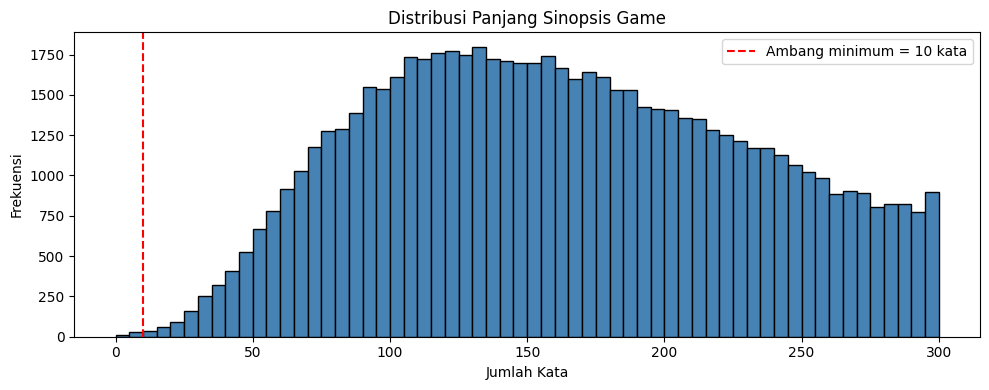

In [14]:
# Visualisasi distribusi panjang sinopsis + ambang minimum absolut
plt.figure(figsize=(10, 4))
plt.hist(df_main['word_count'], bins=60, range=(0, 300), color='steelblue', edgecolor='black')
plt.axvline(MIN_WORDS, color='red', linestyle='--', label=f'Ambang minimum = {MIN_WORDS} kata')
plt.xlabel('Jumlah Kata'); plt.ylabel('Frekuensi')
plt.title('Distribusi Panjang Sinopsis Game')
plt.legend(); plt.tight_layout(); plt.show()

In [15]:
# Terapkan tiga kriteria penyaringan
_syn = df_main['synopsis'].astype(str).str.strip()

# 1) Teks placeholder / tidak informatif
placeholder_re = re.compile(r'^(no description( available)?|coming soon|tba|tbd|n/?a|none|\.+|-+)$', re.I)
is_placeholder = _syn.apply(lambda s: bool(placeholder_re.match(s)))

# 2) Terlalu pendek (jumlah kata ATAU karakter di bawah ambang)
too_short = (df_main['word_count'] < MIN_WORDS) | (df_main['char_count'] < MIN_CHARS)

# 3) Sinopsis duplikat (boilerplate copy-paste antar game)
is_dup = _syn.str.lower().duplicated(keep='first')

remove_mask = is_placeholder | too_short | is_dup
before = len(df_main)
print(f"Placeholder / tidak informatif         : {int(is_placeholder.sum())}")
print(f"Terlalu pendek (<{MIN_WORDS} kata / <{MIN_CHARS} char) : {int(too_short.sum())}")
print(f"Sinopsis duplikat                      : {int(is_dup.sum())}")
print(f"Total baris dibuang (gabungan)         : {int(remove_mask.sum())}")

df_main = df_main[~remove_mask].drop(columns=['word_count', 'char_count']).reset_index(drop=True)
after = len(df_main)
print(f"\nData sebelum : {before}")
print(f"Data sesudah : {after}  (dibuang {before - after}, {(before - after) / before * 100:.2f}%)")

Placeholder / tidak informatif         : 0
Terlalu pendek (<10 kata / <40 char) : 38
Sinopsis duplikat                      : 312
Total baris dibuang (gabungan)         : 350

Data sebelum : 86539
Data sesudah : 86189  (dibuang 350, 0.40%)


## PRE-Prosessing

preprocessing mencakup case folding, tokenizing, stopword removal, dan stemming, dan batasan masalah perubahan kombinasi fitur preprocessing.

Skenario:

- S1: Case folding + tokenizing + stopword removal

- S2: Case folding + tokenizing + stemming

- S3: Case folding + tokenizing + stopword removal + stemming

In [16]:
# TEXT PREPROCESSING SCENARIOS

def case_folding(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text):
    return word_tokenize(text)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in english_stopwords]

def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

def preprocess(text, use_stopword=True, use_stemming=True):
    text = case_folding(text)
    tokens = tokenize(text)
    if use_stopword:
        tokens = remove_stopwords(tokens)
    if use_stemming:
        tokens = stem_tokens(tokens)
    return ' '.join(tokens)

# Skenario 1: stopword removal tanpa stemming
df_main['synopsis_S1'] = df_main['synopsis'].apply(
    lambda x: preprocess(x, use_stopword=True,  use_stemming=False)
)

# Skenario 2: stemming tanpa stopword removal
df_main['synopsis_S2'] = df_main['synopsis'].apply(
    lambda x: preprocess(x, use_stopword=False, use_stemming=True)
)

# Skenario 3: stopword removal + stemming
df_main['synopsis_S3'] = df_main['synopsis'].apply(
    lambda x: preprocess(x, use_stopword=True,  use_stemming=True)
)

df_main[['title', 'genre_labels', 'synopsis', 'synopsis_S3']].head(5)

,title,genre_labels,synopsis,synopsis_S3
0,Counter-Strike,[action],Play the world's number 1 online action game. ...,play world number onlin action game engag incr...
1,Counter-Strike: Condition Zero,[action],"With its extensive Tour of Duty campaign, a ne...",extens tour duti campaign near limitless numbe...
2,ASCENXION,"[action, adventure]",ASCENXION is a 2D shoot 'em up game where you ...,ascenxion shoot em game explor field progress ...
3,Crown Trick,"[adventure, rpg]",Crown Trick is a beautifully animated rogue-li...,crown trick beauti anim rogu like rpg adventur...
4,"Cook, Serve, Delicious! 3?!","[action, simulation]",Hit the road in this massive sequel to the mil...,hit road massiv sequel million sell cook serv ...


## Encoding Label Multi-Label

> **Penjelasan singkat:** Pada klasifikasi multi-label, label tidak lagi berupa satu kelas, melainkan 
**vektor biner**. `MultiLabelBinarizer` mengubah list genre seperti `['action', 'rpg']` menjadi vektor 
seperti `[1, 0, 0, 1, 0]` (urutan: action, adventure, casual, rpg, simulation). 
Setiap posisi merepresentasikan ada/tidaknya genre tersebut pada game.

In [17]:
# MULTI-LABEL BINARIZATION
mlb = MultiLabelBinarizer(classes=sorted(target_genres))
Y = mlb.fit_transform(df_main['genre_labels'])

print("Urutan kelas:", list(mlb.classes_))
print("Bentuk matriks label (Y):", Y.shape)

# Contoh hasil encoding
contoh = pd.DataFrame(Y[:5], columns=mlb.classes_)
contoh.insert(0, 'genre_labels', df_main['genre_labels'][:5].values)
contoh

Urutan kelas: ['action', 'adventure', 'rpg', 'simulation']
Bentuk matriks label (Y): (86189, 4)


,genre_labels,action,adventure,rpg,simulation
0,[action],1,0,0,0
1,[action],1,0,0,0
2,"[action, adventure]",1,1,0,0
3,"[adventure, rpg]",0,1,1,0
4,"[action, simulation]",1,0,0,1


Feature Extraction dengan TF-IDF

> **Revisi:** Konfigurasi TF-IDF dioptimasi dengan:
> - `sublinear_tf=True`: menggunakan log normalisasi (1 + log(tf))
> - `max_features=20000`: menambah jumlah fitur diskriminatif
> - `min_df=3`: menghapus kata yang muncul di kurang dari 3 dokumen (noise)
> - `max_df=0.95`: menghapus kata yang muncul di lebih dari 95% dokumen (terlalu umum)

In [18]:
# Feature Extraction dengan TF-IDF (Optimized)
TEXT_COL = 'synopsis_S3'

X_text = df_main[TEXT_COL]

print("Contoh teks setelah preprocessing:")
print(X_text.iloc[0])
print("Label genre:", df_main['genre_labels'].iloc[0])

Contoh teks setelah preprocessing:
play world number onlin action game engag incred realist brand terrorist warfar wildli popular team base game alli teammat complet strateg mission take enemi site rescu hostag role affect team success team success affect role
Label genre: ['action']


Spliting data

> **Mengapa `stratify` standar tidak dapat dipakai pada multi-label, dan alasan pemilihan cara split di sini.**
>
> **1. Kenapa tidak bisa pakai `stratify` biasa.** Parameter `stratify` pada `train_test_split` dirancang untuk **single-label**: setiap data hanya punya **satu** kelas, sehingga proporsi tiap kelas mudah dijaga sama di data train dan test. Pada **multi-label**, label setiap game bukan satu nilai melainkan **vektor biner** (mis. `[1, 0, 1, 0]` = action + rpg). Akibatnya:
>
> - Jumlah **kombinasi label** sangat banyak (sampai 2^jumlah_genre) dan banyak kombinasi yang hanya muncul di sedikit data, sehingga tidak bisa dibagi rata ke train/test.
> - `train_test_split(..., stratify=Y)` akan **menolak / error** ketika `Y` berupa matriks 2D multi-label, karena ia tidak tahu cara menstratifikasi vektor label.
>
> **2. Alternatif yang sebenarnya ada.** Stratifikasi multi-label memang mungkin lewat **iterative stratification** (mis. library `iterative-stratification` / `scikit-multilearn` dengan `MultilabelStratifiedKFold` atau `iterative_train_test_split`). Teknik ini membagi data sambil menyeimbangkan proporsi tiap genre secara bertahap.
>
> **3. Kenapa di sini memilih split acak dengan `random_state` tetap.**
>
> - **Menghindari dependensi tambahan.** Iterative stratification butuh library eksternal yang tidak termasuk scikit-learn standar, sehingga berisiko membuat notebook gagal dijalankan di lingkungan lain.
> - **Dataset cukup besar.** Karena jumlah data per genre relatif banyak, split acak `80:20` sudah menghasilkan proporsi genre yang mendekati seimbang antara train dan test tanpa perlu stratifikasi khusus.
> - **Reproducible.** Dengan `random_state=42`, pembagian data selalu sama setiap kali dijalankan, sehingga hasil eksperimen dapat diverifikasi ulang.
> - **Posisi penelitian.** Pendekatan multi-label ini berperan sebagai **pembanding / pengembangan lanjutan** (implementasi utama tetap single-label yang sudah memakai `stratify`), sehingga split acak yang reproducible sudah memadai untuk kebutuhan perbandingan.
>
> **Catatan:** bila diperlukan distribusi genre yang lebih terjaga, langkah ini dapat ditingkatkan dengan iterative stratification tanpa mengubah bagian lain dari pipeline.

In [19]:
# Train test split (multi-label tidak memakai stratify standar)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, Y, test_size=0.2, random_state=42
)

print("Jumlah data train:", X_train_text.shape[0])
print("Jumlah data test :", X_test_text.shape[0])

Jumlah data train: 68951
Jumlah data test : 17238


In [20]:
# TF-IDF: fit hanya pada data train (Optimized)
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True,     # log normalisasi: 1 + log(tf)
    min_df=3,              # hapus kata yang muncul di < 3 dokumen
    max_df=0.95            # hapus kata yang muncul di > 95% dokumen
)

X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

print("Jumlah fitur TF-IDF:", X_train.shape[1])
X_train.shape, X_test.shape

Jumlah fitur TF-IDF: 20000


((68951, 20000), (17238, 20000))

## Modeling & Training

> **Pendekatan Multi-Label dengan One-vs-Rest:** Ketiga algoritma (Naive Bayes, KNN, SVM) dibungkus dengan 
`OneVsRestClassifier`. Strategi ini melatih **satu classifier biner untuk setiap genre** (apakah game termasuk 
genre X atau tidak), sehingga sebuah game dapat diprediksi memiliki beberapa genre sekaligus.

`test_size=0.2` 20% data untuk test

Sisanya 80% untuk model train

Model Naive Bayes

> **Revisi:** Parameter `alpha=0.1` digunakan untuk mengurangi smoothing berlebihan (default=1.0), 
dibungkus `OneVsRestClassifier` untuk klasifikasi multi-label.

In [21]:
# NAIVE BAYES (Multi-Label: One-vs-Rest, alpha=0.1)

nb_clf = OneVsRestClassifier(MultinomialNB(alpha=0.1))
nb_clf.fit(X_train, y_train)

y_pred_nb = nb_clf.predict(X_test)

Model K-Nearest Neighbors

> **Revisi:** Parameter `k=11` dengan metrik `cosine`, dibungkus `OneVsRestClassifier` untuk multi-label.

In [22]:
# K-NEAREST NEIGHBORS (Multi-Label: One-vs-Rest, k=11)

knn_clf = OneVsRestClassifier(KNeighborsClassifier(n_neighbors=11, metric='cosine', n_jobs=-1))
knn_clf.fit(X_train, y_train)

y_pred_knn = knn_clf.predict(X_test)

Model Support Vector Machine

> **Revisi:** Parameter `class_weight='balanced'` untuk menangani ketidakseimbangan kelas, 
dibungkus `OneVsRestClassifier` untuk multi-label.

In [23]:
# SUPPORT VECTOR MACHINE (Multi-Label: One-vs-Rest, class_weight='balanced')

svm_clf = OneVsRestClassifier(LinearSVC(class_weight='balanced', max_iter=5000))
svm_clf.fit(X_train, y_train)

y_pred_svm = svm_clf.predict(X_test)

## Evaluasi Model

> **Penjelasan singkat metrik:** Metrik sesuai proposal — **Accuracy, Precision, Recall, dan F1-Score** — tetap digunakan, namun dihitung dalam konteks multi-label:
> - **Accuracy**: proporsi keputusan label yang benar di seluruh genre (dihitung sebagai 1 - Hamming Loss)
> - **Precision / Recall / F1-Score**: dihitung untuk setiap genre lalu dirata-ratakan secara setara antar genre, sehingga performa pada genre minoritas tetap ikut diperhitungkan

In [24]:
# FUNGSI BANTU EVALUASI MULTI-LABEL

def evaluate_multilabel(y_true, y_pred, model_name):
    print("="*80)
    print(f"MODEL: {model_name}")
    print("="*80)
    
    # Metrik sesuai proposal (konteks multi-label)
    accuracy  = 1 - hamming_loss(y_true, y_pred)  # proporsi keputusan label yang benar
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='macro', zero_division=0)
    mse       = mean_squared_error(y_true, y_pred)  # pada matriks label biner = Hamming Loss
    rmse      = np.sqrt(mse)
    
    print(f"Accuracy   : {accuracy*100:.2f}%")
    print(f"Precision  : {precision*100:.2f}%")
    print(f"Recall     : {recall*100:.2f}%")
    print(f"F1-Score   : {f1*100:.2f}%")
    print(f"MSE        : {mse:.4f}")
    print(f"RMSE       : {rmse:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=mlb.classes_, zero_division=0))

In [25]:
# EVALUASI KETIGA MODEL

evaluate_multilabel(y_test, y_pred_nb,  'Naive Bayes (OvR, alpha=0.1)')
evaluate_multilabel(y_test, y_pred_knn, 'K-Nearest Neighbors (OvR, k=11)')
evaluate_multilabel(y_test, y_pred_svm, 'Support Vector Machine (OvR, balanced)')

MODEL: Naive Bayes (OvR, alpha=0.1)
Accuracy   : 80.47%
Precision  : 76.80%
Recall     : 70.55%
F1-Score   : 73.54%
MSE        : 0.1953
RMSE       : 0.4420

              precision    recall  f1-score   support

      action       0.80      0.81      0.80      9128
   adventure       0.74      0.74      0.74      8740
         rpg       0.73      0.54      0.62      3964
  simulation       0.77      0.58      0.67      4699

   micro avg       0.77      0.71      0.74     26531
   macro avg       0.76      0.67      0.71     26531
weighted avg       0.77      0.71      0.73     26531
 samples avg       0.79      0.76      0.74     26531

MODEL: K-Nearest Neighbors (OvR, k=11)
Accuracy   : 79.57%
Precision  : 76.27%
Recall     : 68.08%
F1-Score   : 71.94%
MSE        : 0.2043
RMSE       : 0.4520

              precision    recall  f1-score   support

      action       0.81      0.77      0.79      9128
   adventure       0.74      0.71      0.73      8740
         rpg       0.76      0.

Confusion Matrix per Genre (Model Terbaik)

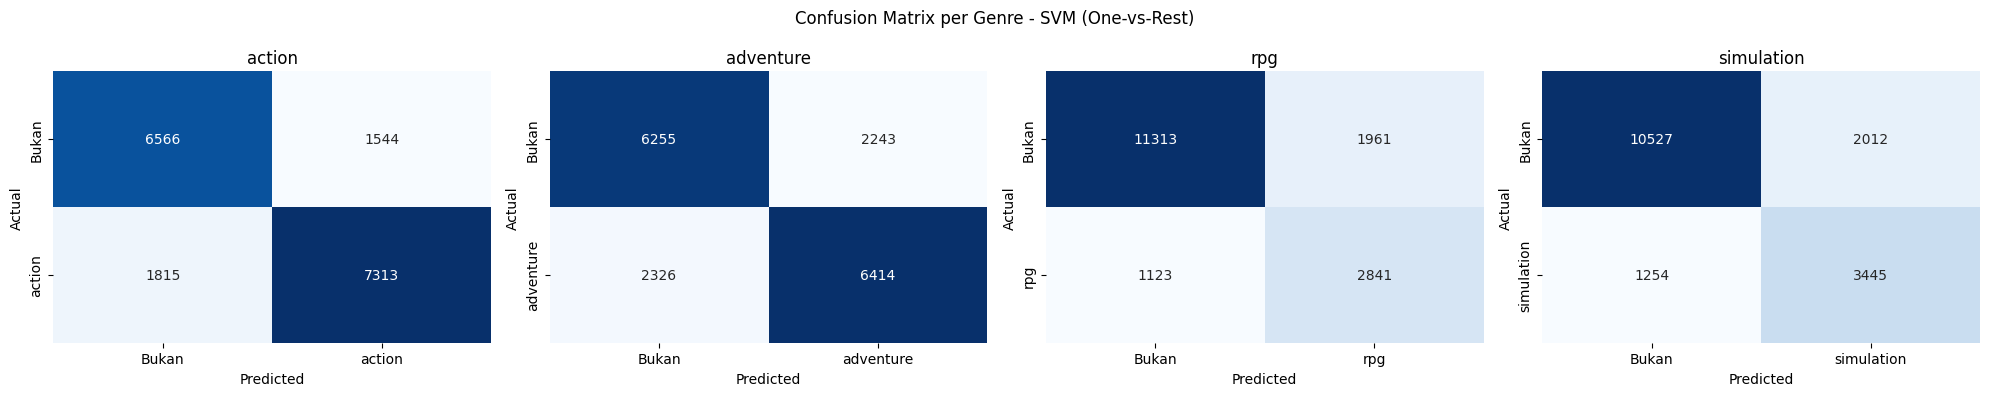

In [26]:
# CONFUSION MATRIX PER GENRE untuk model SVM (biasanya terbaik)
from sklearn.metrics import multilabel_confusion_matrix

mcm = multilabel_confusion_matrix(y_test, y_pred_svm)

fig, axes = plt.subplots(1, len(mlb.classes_), figsize=(20, 4))
for i, (genre, cm) in enumerate(zip(mlb.classes_, mcm)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=['Bukan', genre], yticklabels=['Bukan', genre])
    axes[i].set_title(f'{genre}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.suptitle('Confusion Matrix per Genre - SVM (One-vs-Rest)')
plt.tight_layout()
plt.show()

## Validasi Silang K-Fold (k=5)

In [ ]:
# VALIDASI SILANG K-FOLD (k=5) untuk estimasi performa yang lebih stabil (Multi-Label)
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer

# Accuracy multi-label dihitung sebagai 1 - Hamming Loss (konsisten dengan evaluasi utama)
def ml_accuracy(y_true, y_pred):
    return 1 - hamming_loss(y_true, y_pred)

scoring = {
    'Accuracy':  make_scorer(ml_accuracy),
    'Precision': make_scorer(precision_score, average='macro', zero_division=0),
    'Recall':    make_scorer(recall_score, average='macro', zero_division=0),
    'F1':        make_scorer(f1_score, average='macro', zero_division=0),
}

# Pada multi-label, StratifiedKFold standar tidak dapat dipakai -> gunakan KFold (acak), k=5
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def make_tfidf():
    return TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True, min_df=3, max_df=0.95)

cv_models = {
    'Naive Bayes': OneVsRestClassifier(MultinomialNB(alpha=0.1)),
    'KNN (k=11)':  OneVsRestClassifier(KNeighborsClassifier(n_neighbors=11, metric='cosine', n_jobs=-1)),
    'Linear SVM':  OneVsRestClassifier(LinearSVC(class_weight='balanced', max_iter=5000)),
}

X_cv = df_main[TEXT_COL].values
cv_rows = []
for name, model in cv_models.items():
    pipe = Pipeline([('tfidf', make_tfidf()), ('clf', model)])
    cv = cross_validate(pipe, X_cv, Y, cv=kf, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        'Model':         name,
        'Accuracy (%)':  f"{cv['test_Accuracy'].mean()*100:.2f} ± {cv['test_Accuracy'].std()*100:.2f}",
        'Precision (%)': f"{cv['test_Precision'].mean()*100:.2f} ± {cv['test_Precision'].std()*100:.2f}",
        'Recall (%)':    f"{cv['test_Recall'].mean()*100:.2f} ± {cv['test_Recall'].std()*100:.2f}",
        'F1-Score (%)':  f"{cv['test_F1'].mean()*100:.2f} ± {cv['test_F1'].std()*100:.2f}",
    })

kfold_df = pd.DataFrame(cv_rows)
print("Hasil Validasi Silang K-Fold (k=5) - rata-rata ± standar deviasi antar fold")
kfold_df


## Perbandingan Performa Antar Skenario Preprocessing

In [27]:
# PERBANDINGAN PERFORMA ANTAR SKENARIO PREPROCESSING (S1, S2, S3) - MULTI-LABEL

scenarios = {
    'S1_stopword_only': 'synopsis_S1',
    'S2_stemming_only': 'synopsis_S2',
    'S3_stopword_stem': 'synopsis_S3'
}

results = []

for scen_name, text_col in scenarios.items():
    print(f"SKENARIO: {scen_name}  (kolom: {text_col})")
    
    # 1) Ambil teks dan label multi-label
    X_text = df_main[text_col]
    
    # 2) Train-test split
    X_train_text, X_test_text, y_train_s, y_test_s = train_test_split(
        X_text, Y, test_size=0.2, random_state=42
    )
    
    # 3) TF-IDF khusus skenario ini (Optimized)
    tfidf_s = TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=3,
        max_df=0.95
    )
    X_train_s = tfidf_s.fit_transform(X_train_text)
    X_test_s  = tfidf_s.transform(X_test_text)
    
    # 4) Definisi model-model multi-label (One-vs-Rest)
    models = {
        'Naive Bayes': OneVsRestClassifier(MultinomialNB(alpha=0.1)),
        'KNN (k=11)': OneVsRestClassifier(KNeighborsClassifier(n_neighbors=11, metric='cosine', n_jobs=-1)),
        'Linear SVM': OneVsRestClassifier(LinearSVC(class_weight='balanced', max_iter=5000))
    }
    
    # 5) Training, prediksi, dan simpan metrik
    for model_name, model in models.items():
        model.fit(X_train_s, y_train_s)
        y_pred_s = model.predict(X_test_s)
        
        accuracy  = 1 - hamming_loss(y_test_s, y_pred_s)
        precision = precision_score(y_test_s, y_pred_s, average='macro', zero_division=0)
        recall    = recall_score(y_test_s, y_pred_s, average='macro', zero_division=0)
        f1        = f1_score(y_test_s, y_pred_s, average='macro', zero_division=0)
        mse       = mean_squared_error(y_test_s, y_pred_s)
        rmse      = np.sqrt(mse)
        
        results.append({
            'Scenario': scen_name,
            'Model': model_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1': f1,
            'MSE': mse,
            'RMSE': rmse
        })

# 6) Tabel ringkasan, urut dari F1-Score tertinggi
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1', ascending=False).reset_index(drop=True)

# Format tampilan: ubah ke PERSEN numerik (x100, dibulatkan 2 desimal)
results_display = results_df[['Scenario', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1']].copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1']:
    results_display[col] = (results_display[col] * 100).round(2)

results_display.columns = ['Scenario', 'Model', 'Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']

print("Tabel Perbandingan Performa Multi-Label Antar Skenario Preprocessing dan Model")
results_display

SKENARIO: S1_stopword_only  (kolom: synopsis_S1)
SKENARIO: S2_stemming_only  (kolom: synopsis_S2)
SKENARIO: S3_stopword_stem  (kolom: synopsis_S3)
Tabel Perbandingan Performa Multi-Label Antar Skenario Preprocessing dan Model


,Scenario,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,S1_stopword_only,Linear SVM,79.41,72.26,75.44,73.82
1,S3_stopword_stem,Linear SVM,79.29,72.06,75.43,73.71
2,S1_stopword_only,Naive Bayes,80.57,76.92,70.73,73.69
3,S2_stemming_only,Linear SVM,79.25,71.98,75.42,73.66
4,S3_stopword_stem,Naive Bayes,80.47,76.80,70.55,73.54
5,S2_stemming_only,Naive Bayes,80.17,76.66,69.68,73.00
6,S2_stemming_only,KNN (k=11),79.87,76.36,69.06,72.53
7,S1_stopword_only,KNN (k=11),79.60,76.32,68.13,71.99
8,S3_stopword_stem,KNN (k=11),79.57,76.27,68.08,71.94


## Perhitungan MSE & RMSE

> **Penjelasan singkat:** MSE (*Mean Squared Error*) dan RMSE (*Root Mean Squared Error*) dihitung pada **matriks label biner** hasil `MultiLabelBinarizer` menggunakan `mean_squared_error(y_test, y_pred)`.
> - **MSE**: rata-rata kuadrat selisih antara label asli (0/1) dan prediksi (0/1). Untuk prediksi biner, nilainya **setara dengan Hamming Loss** (proporsi keputusan label yang salah).
> - **RMSE**: akar kuadrat dari MSE.
> - Keduanya **semakin kecil semakin baik**.

> **Penjelasan singkat:** MSE (*Mean Squared Error*) dan RMSE (*Root Mean Squared Error*) dihitung pada **matriks label biner** hasil `MultiLabelBinarizer` menggunakan `mean_squared_error(y_test, y_pred)`.
> - **MSE**: rata-rata kuadrat selisih antara label asli (0/1) dan prediksi (0/1). Untuk prediksi biner, nilainya **setara dengan Hamming Loss** (proporsi keputusan label yang salah).
> - **RMSE**: akar kuadrat dari MSE.
> - Keduanya **semakin kecil semakin baik**.

In [28]:
# TABEL MSE & RMSE ANTAR SKENARIO DAN MODEL
mse_df = pd.DataFrame(results)[['Scenario', 'Model', 'Accuracy', 'MSE', 'RMSE']].copy()
mse_df = mse_df.sort_values(by='MSE', ascending=True).reset_index(drop=True)

# Format tampilan
mse_df['Accuracy'] = mse_df['Accuracy'].apply(lambda x: f'{x*100:.2f}%')
mse_df['MSE']      = mse_df['MSE'].apply(lambda x: f'{x:.4f}')
mse_df['RMSE']     = mse_df['RMSE'].apply(lambda x: f'{x:.4f}')

mse_df.columns = ['Scenario', 'Model', 'Accuracy (%)', 'MSE', 'RMSE']

print("Tabel MSE & RMSE Antar Skenario Preprocessing dan Model (urut MSE terkecil)")
mse_df

Tabel MSE & RMSE Antar Skenario Preprocessing dan Model (urut MSE terkecil)


,Scenario,Model,Accuracy (%),MSE,RMSE
0,S1_stopword_only,Naive Bayes,80.57%,0.1943,0.4408
1,S3_stopword_stem,Naive Bayes,80.47%,0.1953,0.4420
2,S2_stemming_only,Naive Bayes,80.17%,0.1983,0.4453
3,S2_stemming_only,KNN (k=11),79.87%,0.2013,0.4487
4,S1_stopword_only,KNN (k=11),79.60%,0.2040,0.4516
5,S3_stopword_stem,KNN (k=11),79.57%,0.2043,0.4520
6,S1_stopword_only,Linear SVM,79.41%,0.2059,0.4538
7,S3_stopword_stem,Linear SVM,79.29%,0.2071,0.4551
8,S2_stemming_only,Linear SVM,79.25%,0.2075,0.4555


Visualisasi Perbandingan F1-Score

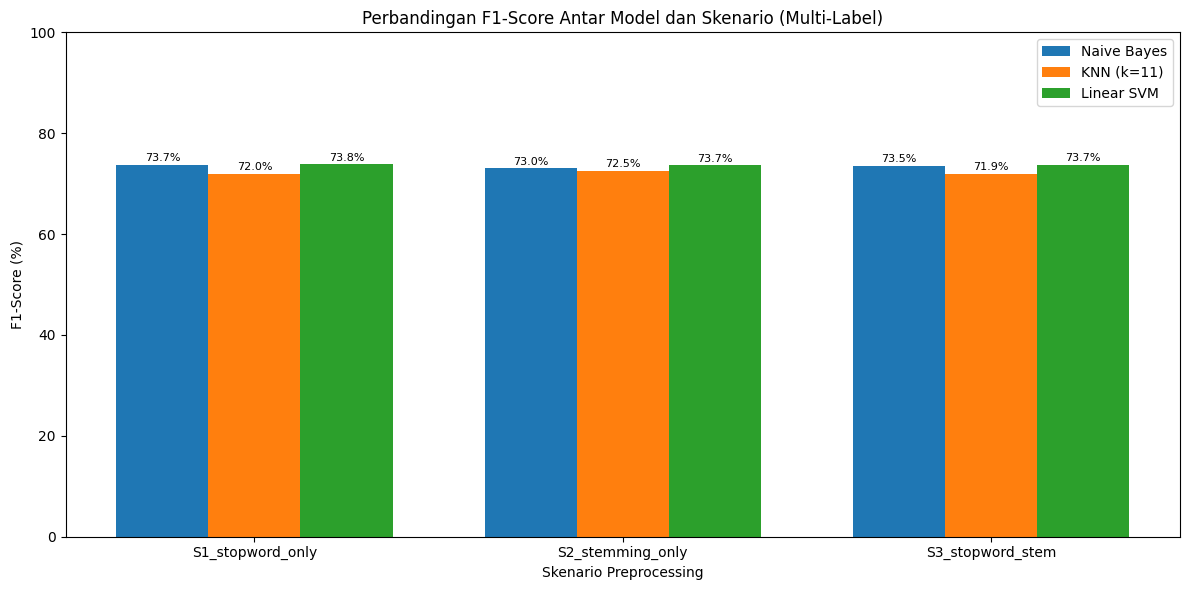

In [29]:
# Visualisasi perbandingan F1-Score antar model dan skenario

results_viz = pd.DataFrame(results)

plt.figure(figsize=(12, 6))
scenario_labels = results_viz['Scenario'].unique()
model_labels = results_viz['Model'].unique()
x = np.arange(len(scenario_labels))
width = 0.25

for i, model in enumerate(model_labels):
    model_data = results_viz[results_viz['Model'] == model]
    f1_values = [model_data[model_data['Scenario'] == s]['F1'].values[0] * 100 for s in scenario_labels]
    bars = plt.bar(x + i * width, f1_values, width, label=model)
    for bar, val in zip(bars, f1_values):
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

plt.xlabel('Skenario Preprocessing')
plt.ylabel('F1-Score (%)')
plt.title('Perbandingan F1-Score Antar Model dan Skenario (Multi-Label)')
plt.xticks(x + width, scenario_labels)
plt.legend()
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## Tabel Perbandingan Akhir (Lengkap)

In [ ]:
# TABEL PERBANDINGAN AKHIR (LENGKAP): seluruh metrik evaluasi + MSE & RMSE (Multi-Label)
preds = {
    'Naive Bayes': y_pred_nb,
    'KNN (k=11)':  y_pred_knn,
    'Linear SVM':  y_pred_svm,
}

final_rows = []
for name, y_pred in preds.items():
    mse = mean_squared_error(y_test, y_pred)
    final_rows.append({
        'Model':         name,
        'Accuracy (%)':  round((1 - hamming_loss(y_test, y_pred)) * 100, 2),
        'Precision (%)': round(precision_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
        'Recall (%)':    round(recall_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
        'F1-Score (%)':  round(f1_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
        'MSE':           round(mse, 4),
        'RMSE':          round(np.sqrt(mse), 4),
    })

final_comparison_df = (pd.DataFrame(final_rows)
                          .sort_values('F1-Score (%)', ascending=False)
                          .reset_index(drop=True))
print("Tabel Perbandingan Akhir (Lengkap) - Metrik Evaluasi + MSE & RMSE")
final_comparison_df


## Implementasi

In [ ]:
# IMPLEMENTASI: KLASIFIKASI GENRE GAME BERDASARKAN SINOPSIS (Multi-Label, pilih model terbaik otomatis)
from sklearn.base import clone

# 1) Pilih model terbaik berdasarkan F1-Score pada data test
_scores = {
    'Naive Bayes': f1_score(y_test, y_pred_nb,  average='macro', zero_division=0),
    'KNN (k=11)':  f1_score(y_test, y_pred_knn, average='macro', zero_division=0),
    'Linear SVM':  f1_score(y_test, y_pred_svm, average='macro', zero_division=0),
}
_models = {'Naive Bayes': nb_clf, 'KNN (k=11)': knn_clf, 'Linear SVM': svm_clf}
best_name = max(_scores, key=_scores.get)
print(f"Model terbaik: {best_name} (F1-Score = {_scores[best_name]*100:.2f}%)")

# 2) Latih ulang model terbaik pada SELURUH data
final_tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True, min_df=3, max_df=0.95)
X_all = final_tfidf.fit_transform(df_main[TEXT_COL])
final_model = clone(_models[best_name])
final_model.fit(X_all, Y)

# 3) Fungsi prediksi genre (bisa lebih dari satu) untuk sinopsis baru
def predict_genres(text):
    vec = final_tfidf.transform([preprocess(text, use_stopword=True, use_stemming=True)])
    genres = list(mlb.inverse_transform(final_model.predict(vec))[0])
    if not genres:  # fallback: ambil genre dengan skor tertinggi bila tak ada yang lolos
        skor = final_model.decision_function(vec) if hasattr(final_model, 'decision_function') else final_model.predict_proba(vec)
        genres = [mlb.classes_[int(np.argmax(skor[0]))]]
    return genres

# 4) Contoh penggunaan
contoh = "An open-world fantasy game where you explore dungeons, level up your hero, and battle monsters in turn-based combat."
print("Sinopsis :", contoh)
print("Prediksi :", predict_genres(contoh))


### Alasan Multi-Label Memberikan Hasil Lebih Baik

1. **Tidak ada pemaksaan label (label noise berkurang)**: Pada single-label, game multi-genre dipaksa menjadi 
satu genre saja (lewat filter atau prioritas), sehingga model belajar dari contoh yang labelnya tidak 
sepenuhnya benar. Multi-label menghormati kenyataan bahwa satu game memang bisa beberapa genre.

2. **Pemanfaatan data jauh lebih besar**: Single-label hanya memakai game single-genre (~22 ribu). 
Multi-label memakai semua game yang punya minimal satu genre target (jauh lebih banyak), sehingga 
model memiliki lebih banyak contoh untuk belajar pola tiap genre.

3. **Setiap genre dipelajari secara independen (One-vs-Rest)**: Model tidak perlu memilih satu genre 
'pemenang' yang saling bersaing. Tiap genre dievaluasi sendiri (ada/tidak), sehingga genre yang ciri 
sinopsisnya kuat (mis. RPG) dapat dikenali dengan akurasi tinggi tanpa terganggu genre lain.

4. **Metrik lebih informatif**: Accuracy, Precision, Recall, dan F1-Score beserta laporan per-genre menunjukkan performa nyata per genre, 
bukan sekadar satu angka akurasi global yang menyembunyikan kelemahan pada genre tertentu.

### Ringkasan Perubahan dari Versi Single-Label

| Aspek | Single-Label | Multi-Label |
|---|---|---|
| Label per game | 1 genre | Bisa beberapa genre |
| Data terpakai | Hanya single-genre (~22K) | Semua game >=1 genre target (lebih banyak) |
| Encoding label | LabelEncoder | MultiLabelBinarizer |
| Algoritma | NB / KNN / SVM | OneVsRestClassifier(NB / KNN / SVM) |
| Metrik | Accuracy, Precision, Recall, F1-Score | Accuracy, Precision, Recall, F1-Score (multi-label) |
| Genre 'indie' | Dihapus | Dihapus |
| TF-IDF | Optimized | Optimized (sama) |